# From one daily price peak to two?

The day-ahead price used to have roughly one daily shape: low overnight,
rising through the morning, staying elevated through the day, peaking in
the evening. The claim worth checking is that this has changed -- as PV
capacity grew (see `10_pv_capture_rate`), midday prices get pushed down
while the plants still setting the price in the morning and evening ramp
don't, splitting one broad daytime peak into two separate ones either side
of a solar-driven midday trough.

That shape matters directly for battery arbitrage: a battery wants a big
spread between its cheapest and most expensive hours *and* a well-defined
trough to charge into, ideally twice a day rather than once. This page
checks three things against SMARD's DE-LU day-ahead price: (1) has the
daily min-max spread grown, (2) same question at monthly/annual
resolution where a trend is actually readable, and (3) has the average
daily *shape* itself become more two-humped -- checked separately for
summer and winter, since PV-driven midday suppression is a summer story
and mixing the two seasons would just wash it out.

In [1]:
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from insights.paths import hub_file

MIN_COLOR = "#2a78d6"     # dataviz skill categorical slot 1 (blue) -- cool = daily low
MAX_COLOR = "#eb6834"     # dataviz skill categorical slot 2 (orange) -- warm = daily high
SPREAD_COLOR = "#1baf7a"  # dataviz skill categorical slot 3 (aqua)
WINTER_CMAP = "Blues"     # cool season -> blue sequential ramp
SUMMER_CMAP = "Oranges"   # warm season -> orange sequential ramp, the skill's own
                          # rule for a second simultaneous sequential context

price = pd.read_parquet(hub_file("smard", "price_de_lu.parquet"))
price.tail()

,price_de_lu
timestamp,
2026-09-24 17:00:00,267.32
2026-09-24 18:00:00,260.00
2026-09-24 19:00:00,225.82
2026-09-24 20:00:00,204.87
2026-09-24 21:00:00,188.01


## Daily min vs. max: does a full-history plot even work?

The most direct version of the question -- one point (or band) per day,
~2,900 of them. The current, still-incomplete day is dropped.

In [2]:
current_day = pd.Timestamp.today().normalize()

daily = pd.DataFrame({
    "min": price["price_de_lu"].resample("D").min(),
    "max": price["price_de_lu"].resample("D").max(),
})
daily = daily[daily.index < current_day]
daily["spread"] = daily["max"] - daily["min"]
daily.tail()

,min,max,spread
timestamp,,,
2026-09-20,-1.98,86.65,88.63
2026-09-21,0.00,242.98,242.98
2026-09-22,116.02,596.38,480.36
2026-09-23,57.32,346.08,288.76
2026-09-24,11.60,267.32,255.72


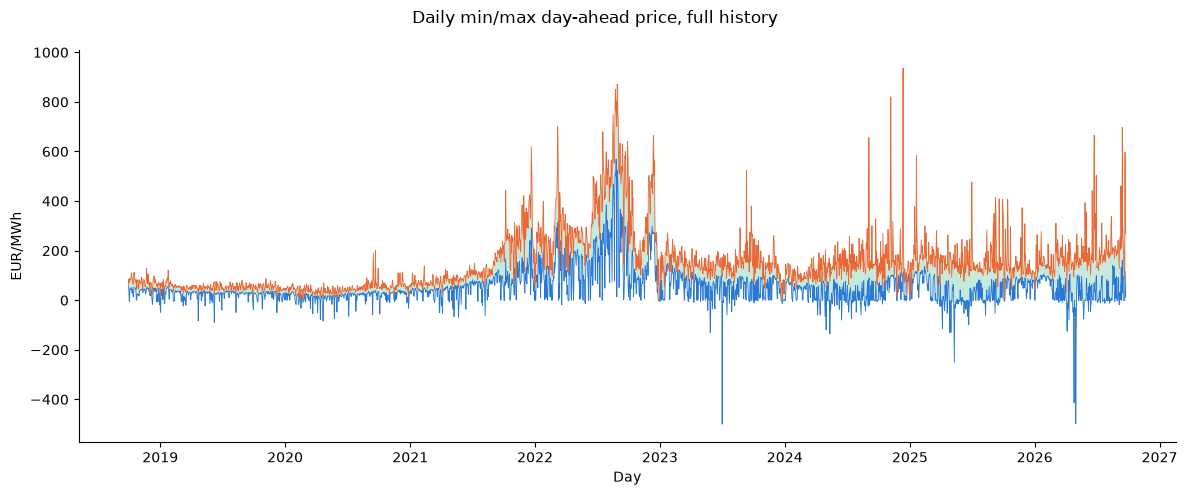

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(daily.index, daily["min"], daily["max"], color=SPREAD_COLOR, alpha=0.25, linewidth=0)
ax.plot(daily.index, daily["min"], color=MIN_COLOR, linewidth=0.6)
ax.plot(daily.index, daily["max"], color=MAX_COLOR, linewidth=0.6)
ax.set_ylabel("EUR/MWh")
ax.set_xlabel("Day")
ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Daily min/max day-ahead price, full history")
fig.tight_layout()
plt.show()

Readable as a "does the band widen" check -- and it clearly does, 2022's
crisis aside -- but daily noise dominates any within-band detail, and a
single wide day here and there tells you nothing about whether that's
becoming typical. Monthly and annual averages of the same `spread` column
are the better view for an actual trend.

## Monthly and annual average spread

`spread` averaged per calendar month, then per year -- same
current-period exclusion as `07_ttf_gas_vs_power_price` and
`10_pv_capture_rate`. 2018 is dropped from the annual view too: the price
series only starts 2018-09-30, so a 2018 bucket would average three
unrepresentative autumn months against full years everywhere else.

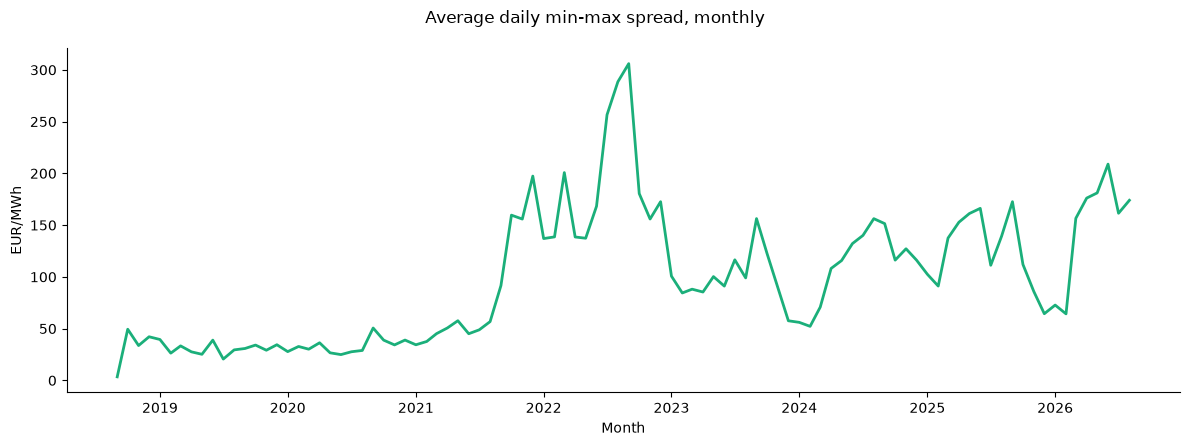

In [4]:
current_month = pd.Timestamp.today().to_period("M")
monthly_spread = daily["spread"].resample("MS").mean()
monthly_spread = monthly_spread[monthly_spread.index.to_period("M") < current_month]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(monthly_spread.index, monthly_spread, color=SPREAD_COLOR, linewidth=2)
ax.set_ylabel("EUR/MWh")
ax.set_xlabel("Month")
ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Average daily min-max spread, monthly")
fig.tight_layout()
plt.show()

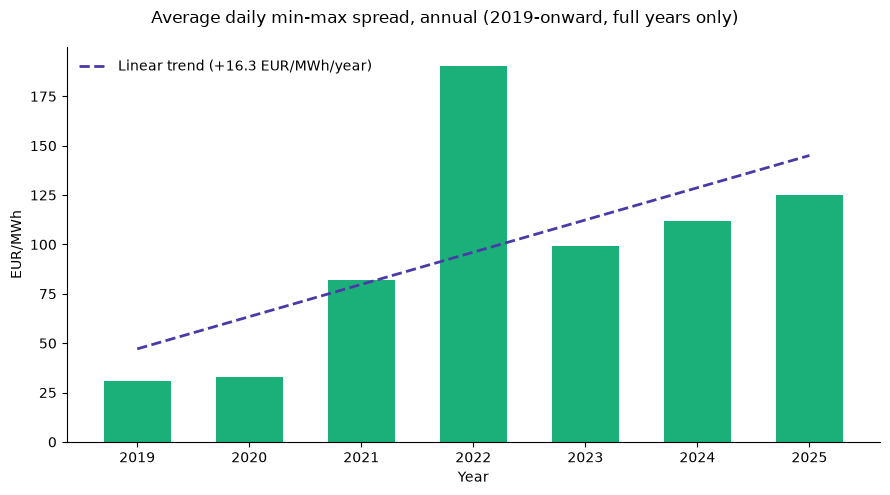

Linear trend: +16.3 EUR/MWh per year
2019: 31 EUR/MWh -> 2025: 125 EUR/MWh


In [5]:
current_year = pd.Timestamp.today().to_period("Y")
annual_spread = daily["spread"].resample("YS").mean()
annual_spread = annual_spread[(annual_spread.index.to_period("Y") < current_year) & (annual_spread.index.year >= 2019)]
annual_spread.index = annual_spread.index.year

slope, intercept = np.polyfit(annual_spread.index.values, annual_spread.values, 1)
trend = slope * annual_spread.index.values + intercept

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(annual_spread.index, annual_spread.values, color=SPREAD_COLOR, width=0.6)
ax.plot(annual_spread.index, trend, color="#4a3aa7", linewidth=2, linestyle="--", label=f"Linear trend ({slope:+.1f} EUR/MWh/year)")
ax.set_ylabel("EUR/MWh")
ax.set_xlabel("Year")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", frameon=False)
fig.suptitle("Average daily min-max spread, annual (2019-onward, full years only)")
fig.tight_layout()
plt.show()

print(f"Linear trend: {slope:+.1f} EUR/MWh per year")
print(f"{annual_spread.index.min()}: {annual_spread.iloc[0]:.0f} EUR/MWh -> {annual_spread.index.max()}: {annual_spread.iloc[-1]:.0f} EUR/MWh")

The average daily spread roughly quadrupled from 2019 to 2025 (2022's gas
crisis is a one-year spike on top of that trend, not the source of it --
2023-2025 stay well above the pre-crisis level). More spread, on its own,
just means "more arbitrage opportunity" -- it says nothing yet about
*shape*, which is what the next section looks at.

## Average daily shape, by season and year

One average hourly curve per season-year: for every hour of the day (0-23),
the mean price across all days of that season in that year. Summer =
June-August. Winter = December-February, labeled by the January it
contains (so "winter 2019" = Dec 2018 + Jan-Feb 2019) -- the standard
meteorological-winter convention, needed because December and
January/February would otherwise land in different calendar years. Only
seasons that have fully completed are kept, same exclusion logic as the
monthly/annual views above.

In [6]:
hourly = price.copy()
hourly["hour"] = hourly.index.hour
hourly["month"] = hourly.index.month
hourly["summer_year"] = hourly.index.year
hourly["winter_year"] = np.where(hourly["month"] == 12, hourly.index.year + 1, hourly.index.year)

SUMMER_MONTHS = [6, 7, 8]
WINTER_MONTHS = [12, 1, 2]

summer_curves = (
    hourly[hourly["month"].isin(SUMMER_MONTHS)]
    .groupby(["summer_year", "hour"])["price_de_lu"].mean()
    .unstack("hour")
)
summer_curves = summer_curves[[pd.Period(f"{y}-08") < current_month for y in summer_curves.index]]

winter_curves = (
    hourly[hourly["month"].isin(WINTER_MONTHS)]
    .groupby(["winter_year", "hour"])["price_de_lu"].mean()
    .unstack("hour")
)
winter_curves = winter_curves[[pd.Period(f"{y}-02") < current_month for y in winter_curves.index]]

print(f"Summer seasons: {list(summer_curves.index)}")
print(f"Winter seasons: {list(winter_curves.index)}")

Summer seasons: [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
Winter seasons: [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


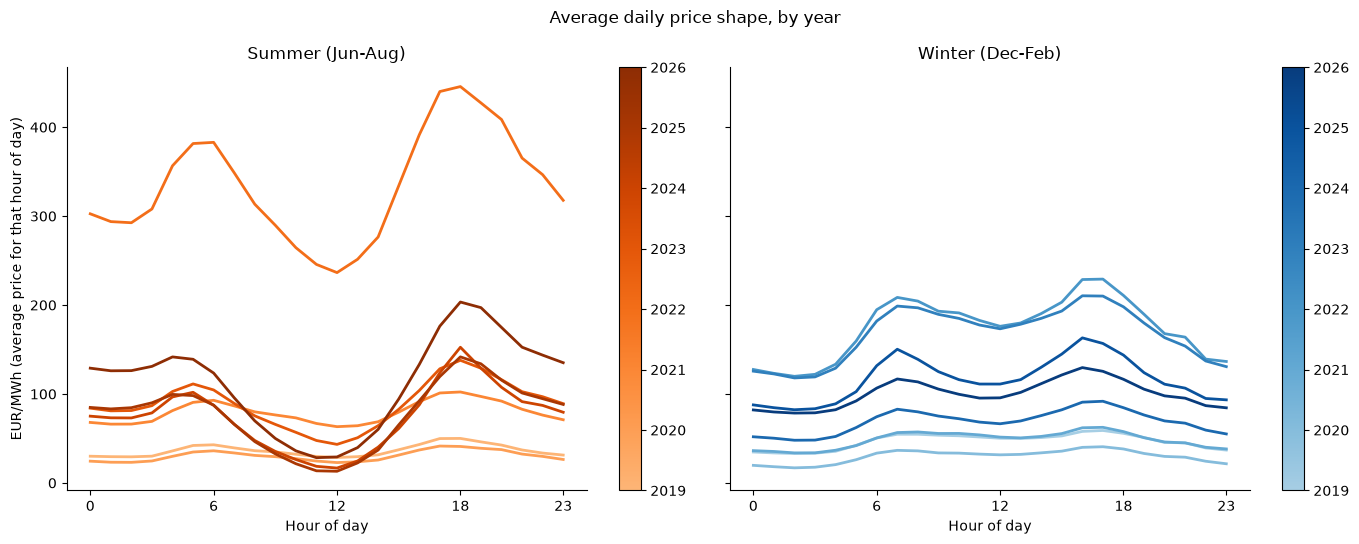

In [7]:
def plot_seasonal_curves(ax, curves, cmap_name, title):
    years = curves.index.to_numpy()
    cmap = mpl.colormaps[cmap_name]
    positions = np.linspace(0.35, 0.95, len(years))
    for year, pos in zip(years, positions):
        ax.plot(curves.columns, curves.loc[year], color=cmap(pos), linewidth=2)
    ax.set_xlabel("Hour of day")
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(title)
    norm = mcolors.Normalize(vmin=years.min(), vmax=years.max())
    sm = cm.ScalarMappable(cmap=mcolors.LinearSegmentedColormap.from_list("", [cmap(p) for p in positions]), norm=norm)
    cbar = plt.colorbar(sm, ax=ax, ticks=years)
    cbar.ax.set_yticklabels([str(y) for y in years])


fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
plot_seasonal_curves(axes[0], summer_curves, SUMMER_CMAP, "Summer (Jun-Aug)")
plot_seasonal_curves(axes[1], winter_curves, WINTER_CMAP, "Winter (Dec-Feb)")
axes[0].set_ylabel("EUR/MWh (average price for that hour of day)")
fig.suptitle("Average daily price shape, by year")
fig.tight_layout()
plt.show()

The two panels tell different stories, exactly as expected. **Summer**
starts (2019-2021) as one broad daytime hump with only a shallow midday
dip; by 2023-2026 that dip has turned into a deep trough with two clearly
separate peaks either side of it -- a small morning one and a larger
evening one, opening up right around the hours PV output is highest.
**Winter** stays essentially one-humped throughout, 2019 through 2026 --
with little PV output to suppress midday demand-driven prices in the
first place, there's no mechanism here to split the peak. That contrast
is itself the check on the hypothesis: the shape change tracks the
season where PV actually produces, not the calendar in general.